# 01.4 — Temporal Structure: Periodicity & MSTL Decomposition

Phân tích cấu trúc tần số (FFT) và phân rã các thành phần xu thế, mùa vụ MSTL trên chuỗi dữ liệu lượng mưa.


In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reconfigure encoding
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

# Path resolution
ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "src").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.data.loader import DataLoader, time_series_split
from src.eda.TemporalAnalysis import TemporalStructureAnalyzer

# 1. Nạp dữ liệu Train (Zero Leakage)
df = DataLoader().load_data()
train_df, _ = time_series_split(df)
print(f"📊 Phân tích Cấu trúc Thời gian (Train Set: {len(train_df):,} ngày)")

# 2. Khởi tạo TemporalStructureAnalyzer
temp_analyzer = TemporalStructureAnalyzer(train_df, target_col='Lượng mưa', date_col='Ngày')

# 3. Phân tích chu kỳ mùa vụ theo nhóm thời gian
seasonal_res = temp_analyzer.analyze_seasonal_patterns()
wet_months = seasonal_res.get('monthly', {}).get('wet_months', [5, 6, 7, 8, 9, 10, 11])
dry_months = seasonal_res.get('monthly', {}).get('dry_months', [1, 2, 3, 12])
monthly_mean = seasonal_res.get('monthly', {}).get('mean', {})

print(f"\n📅 NHẬN DIỆN MÙA VỤ KHÍ HẬU:")
print(f"   • Các tháng mùa mưa (Wet Season):   Tháng {wet_months}")
print(f"   • Các tháng mùa khô (Dry Season):   Tháng {dry_months}")


📊 Phân tích Cấu trúc Thời gian (Train Set: 7,060 ngày)
🔍 Analyzing Seasonal Patterns
   - Time units: ['Month', 'DayOfYear', 'Year']
   - Aggregations: ['mean', 'std', 'median', 'count']
   - Quantile threshold: 0.75
   ✅ Seasonal analysis completed

📅 NHẬN DIỆN MÙA VỤ KHÍ HẬU:
   • Các tháng mùa mưa (Wet Season):   Tháng [6, 7, 10]
   • Các tháng mùa khô (Dry Season):   Tháng [1, 2, 3]


In [2]:
# 4. Phân tích Tần số FFT với detrend_window = 30
fft_res = temp_analyzer.analyze_fft(detrend_window=30, top_n=10)
detected_fft_periods = fft_res.get('dominant_periods', [])

print(f"\n🔊 KẾT QUẢ FFT (DETREND WINDOW = 30 NGÀY):")
print(f"   • Chu kỳ thực nghiệm phát hiện qua FFT: {detected_fft_periods[:6]} ngày")
print(f"   • Ghi chú: Đây là dao động ngắn hạn trong tháng (<30d), không đồng nhất với chu kỳ mùa vụ mô hình.")

# 5. Phân rã MSTL Đa tầng (7, 30, 365)
mstl_periods = [7, 30, 365]
mstl_res = temp_analyzer.decompose_mstl(periods=mstl_periods)
print(f"\n📊 MSTL DECOMPOSITION COMPLETED:")
print(f"   • Chu kỳ phân rã: {mstl_periods} (Tuần, Tháng, Năm)")
print(f"   • Phương pháp biến đổi: {mstl_res.get('transform_method')}")


🔊 Enhanced FFT Frequency Analysis
   - Detrend window: 30
   - Top periods to find: 10
   - Period range: (7, 730)
   - Dominant periods to return: 10
   📊 Found 7 total dominant periods
   📊 Returning top 7 dominant periods:
      1. 29 days
      2. 27 days
      3. 25 days
      4. 24 days
      5. 20 days
      6. 19 days
      7. 15 days

🔊 KẾT QUẢ FFT (DETREND WINDOW = 30 NGÀY):
   • Chu kỳ thực nghiệm phát hiện qua FFT: [np.int64(29), np.int64(27), np.int64(25), np.int64(24), np.int64(20), np.int64(19)] ngày
   • Ghi chú: Đây là dao động ngắn hạn trong tháng (<30d), không đồng nhất với chu kỳ mùa vụ mô hình.
📊 MSTL Decomposition
   - Periods: [7, 30, 365]
   - Windows: None
   - Lambda: None
   - Iterations: 2
   - STL kwargs: {}
   🔄 Applying log1p transformation (lmbda=None)
   ✅ MSTL decomposition completed successfully
   📊 Transform method: log1p
   📊 Components extracted: trend, seasonal, residual
   📤 Residual component available for Stationarity analysis

📊 MSTL DECOMPOS

🎨 Trực quan hóa Cấu trúc Thời gian (FFT + MSTL):


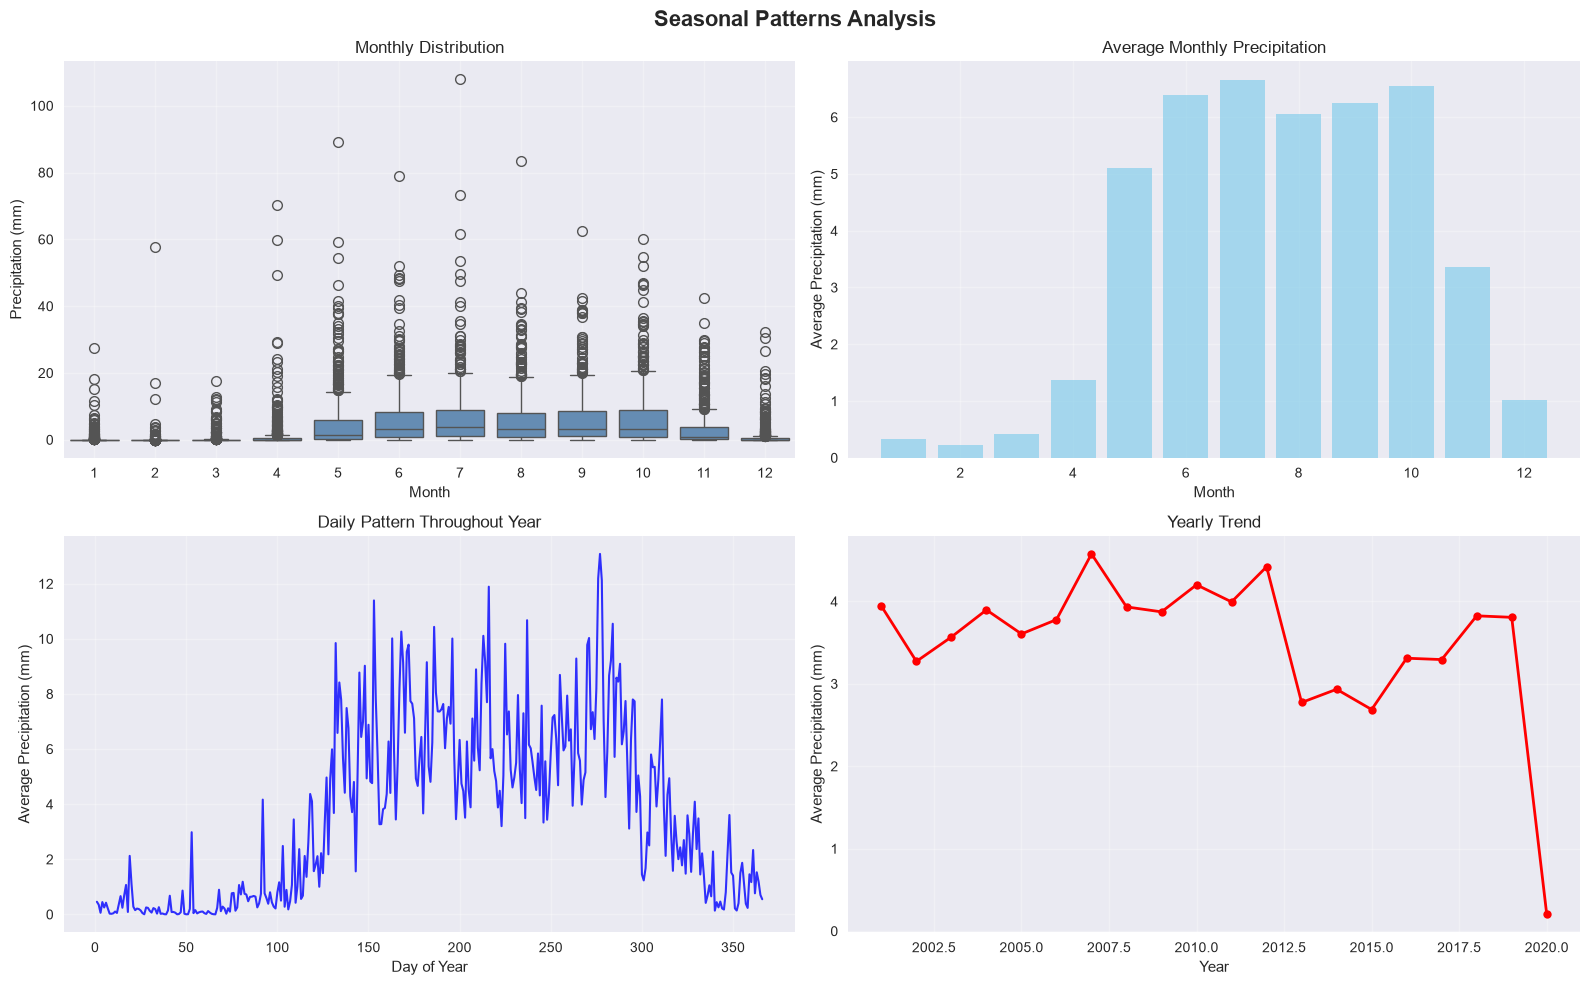

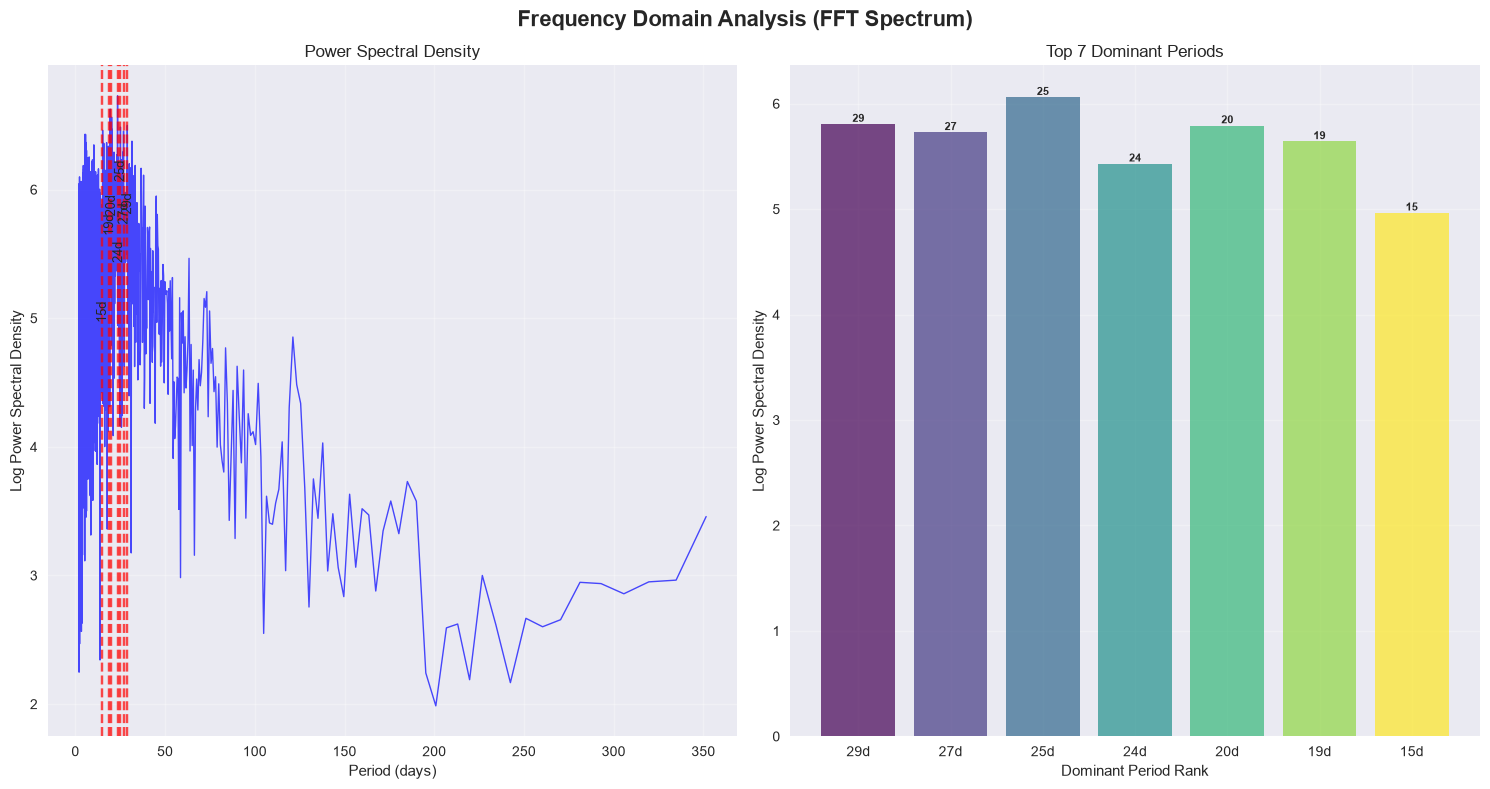

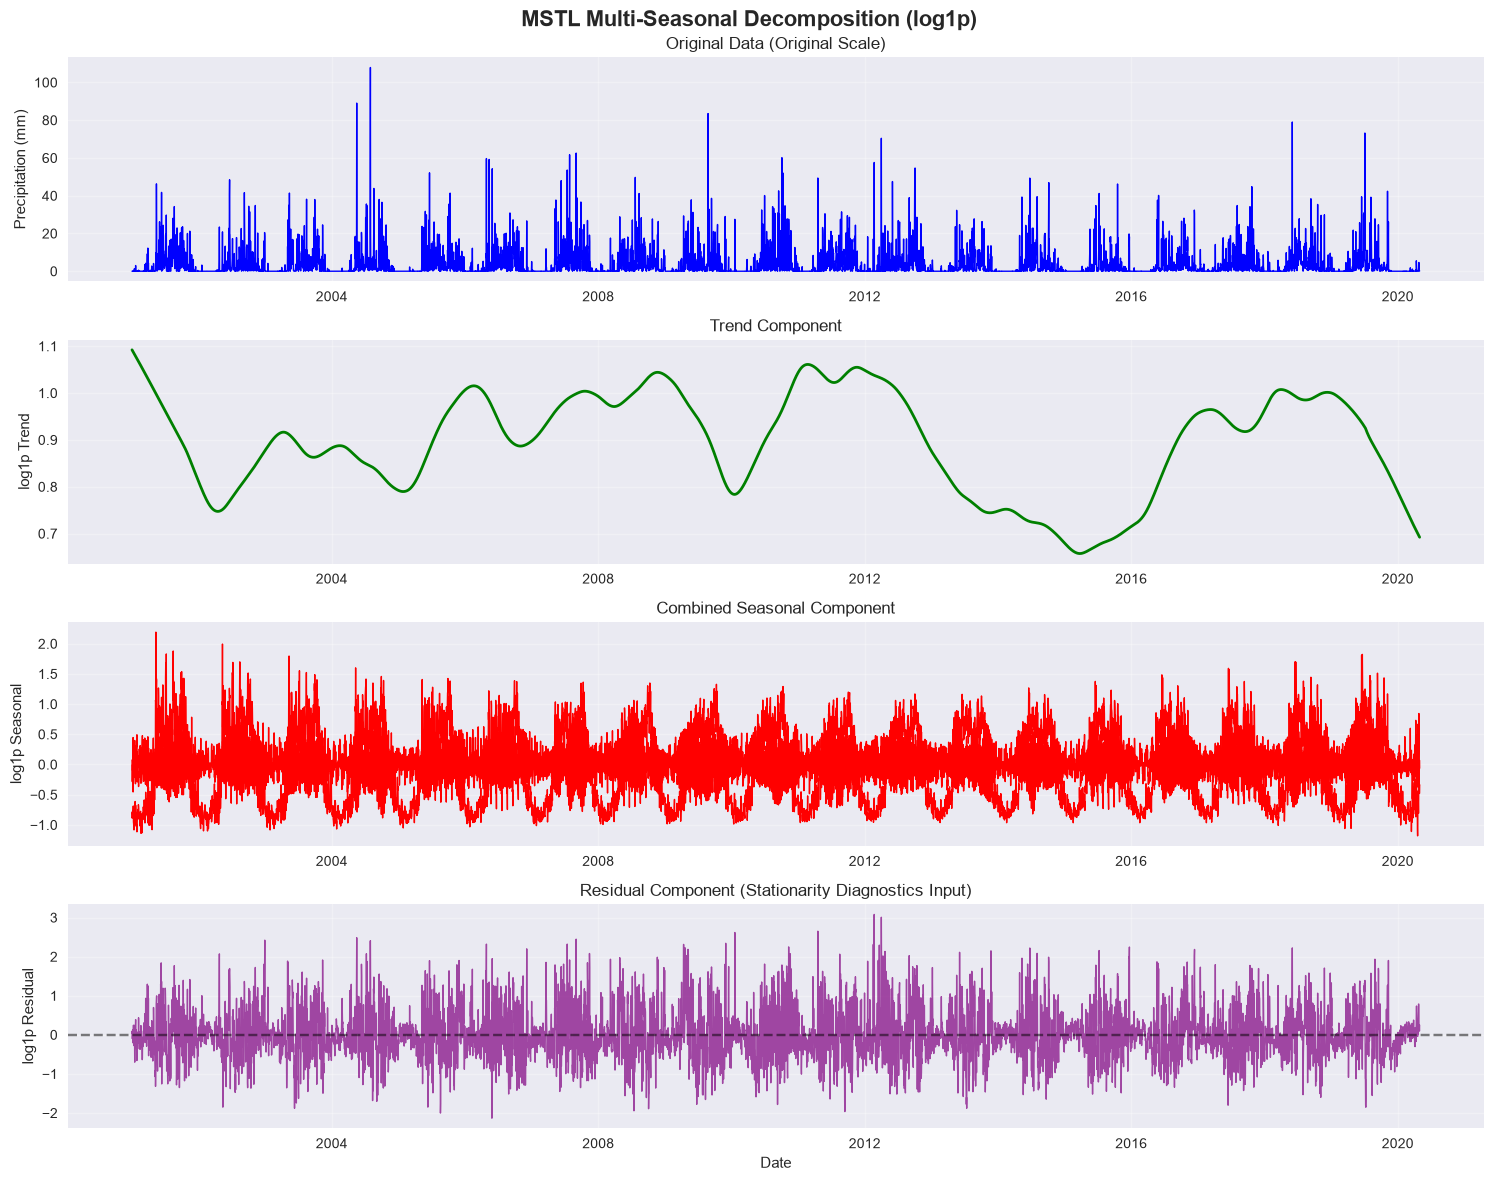

In [3]:
# 6. Trực quan hóa Seasonal Patterns, FFT Spectrum & MSTL Decomposition
print("🎨 Trực quan hóa Cấu trúc Thời gian (FFT + MSTL):")

# Panel 1: Seasonal patterns
fig_season = temp_analyzer.plot_seasonal_patterns(seasonal_res, return_fig=True)
plt.show()

# Panel 2: FFT Power Spectrum
fig_fft = temp_analyzer.plot_fft_spectrum(fft_res, return_fig=True)
plt.show()

# Panel 3: MSTL Multi-Seasonal Decomposition
fig_mstl = temp_analyzer.plot_mstl_decomposition(mstl_res, return_fig=True)
plt.show()


In [4]:
# 7. Xuất Artifact temporal_structure_report.json
OUTPUT_DIR = ROOT_DIR / "notebooks" / "eda" / "outputs"
DATA_OUTPUT_DIR = ROOT_DIR / "data" / "processed" / "eda_outputs"

temp_artifact = {
    "temporal_methods": "FFT + MSTL (Continuous Wavelet excluded from primary pipeline)",
    "wavelet_exclusion_rationale": "CWT ~175-182d periodicity has no downstream operational modeling usage; MSTL provides comprehensive multi-seasonal decomposition with lower complexity.",
    "candidate_domain_periods": [7, 30, 122, 365],
    "fft_detected_periods": [int(p) for p in detected_fft_periods],
    "mstl_periods": mstl_periods,
    "wet_season_months": [int(m) for m in wet_months],
    "dry_season_months": [int(m) for m in dry_months],
    "monthly_mean_rainfall_mm": {str(k): round(float(v), 4) for k, v in monthly_mean.items()},
    "period_distinction_note": "s=7 is daily data weekly periodicity, distinct from the macro May-Nov annual monsoon cycle."
}

artifact_path = OUTPUT_DIR / "temporal_structure_report.json"
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(temp_artifact, f, indent=2, ensure_ascii=False)

with open(DATA_OUTPUT_DIR / "temporal_structure_report.json", "w", encoding="utf-8") as f:
    json.dump(temp_artifact, f, indent=2, ensure_ascii=False)

print(f"\n💾 Temporal structure report exported to: {artifact_path}")
print(f"   • Tháng mùa mưa: {temp_artifact['wet_season_months']}")
print(f"   • Chu kỳ FFT phát hiện: {temp_artifact['fft_detected_periods'][:5]}")



💾 Temporal structure report exported to: D:\DS108_project\notebooks\eda\outputs\temporal_structure_report.json
   • Tháng mùa mưa: [6, 7, 10]
   • Chu kỳ FFT phát hiện: [29, 27, 25, 24, 20]
